In [1]:
#import spatialdata as sd
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc

import squidpy as sq
import anndata as ad

 
import pickle
from matplotlib.colors import ListedColormap
import warnings

warnings.simplefilter("ignore", FutureWarning)

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "fig4"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))


# Load

In [3]:
FILE_NAME = "adata_combined_new.h5ad.final.filtered"
PATH2=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'
adata_5k=sc.read_h5ad(PATH2)
adata_5k=adata_5k[adata_5k.obs["tech"]=="xenium"]


def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST

 
 

In [4]:
with open('/nfs/team298/ls34/niche_colors.pkl', 'rb') as f:
    colors_new2 = pickle.load(f)
 

In [5]:
sc.settings.set_figure_params(dpi_save=600, facecolor="white", frameon=False, figsize=(7,7))

NICHE =  'Plasma_cell_rich'
MIN_NUMBER_CELLS=10

CORE_PAPER =["BK23_Week 12",
                                       "BK27_Week 12",
                                      'BK27_Lesional Baseline',
                                         'BK24_Lesional Baseline']

In [6]:
import pickle
#NICHE11="Tzone-like"
MINIMUM_PERCENT = 0.05
COLOR_PICKLE_PATH =  '/nfs/team298/ls34/color_for_adult_skin2.pkl'

with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

In [7]:
90

90

/tmp/ipykernel_3836113/2300984721.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_5k.obs["info_id7"] = np.where(


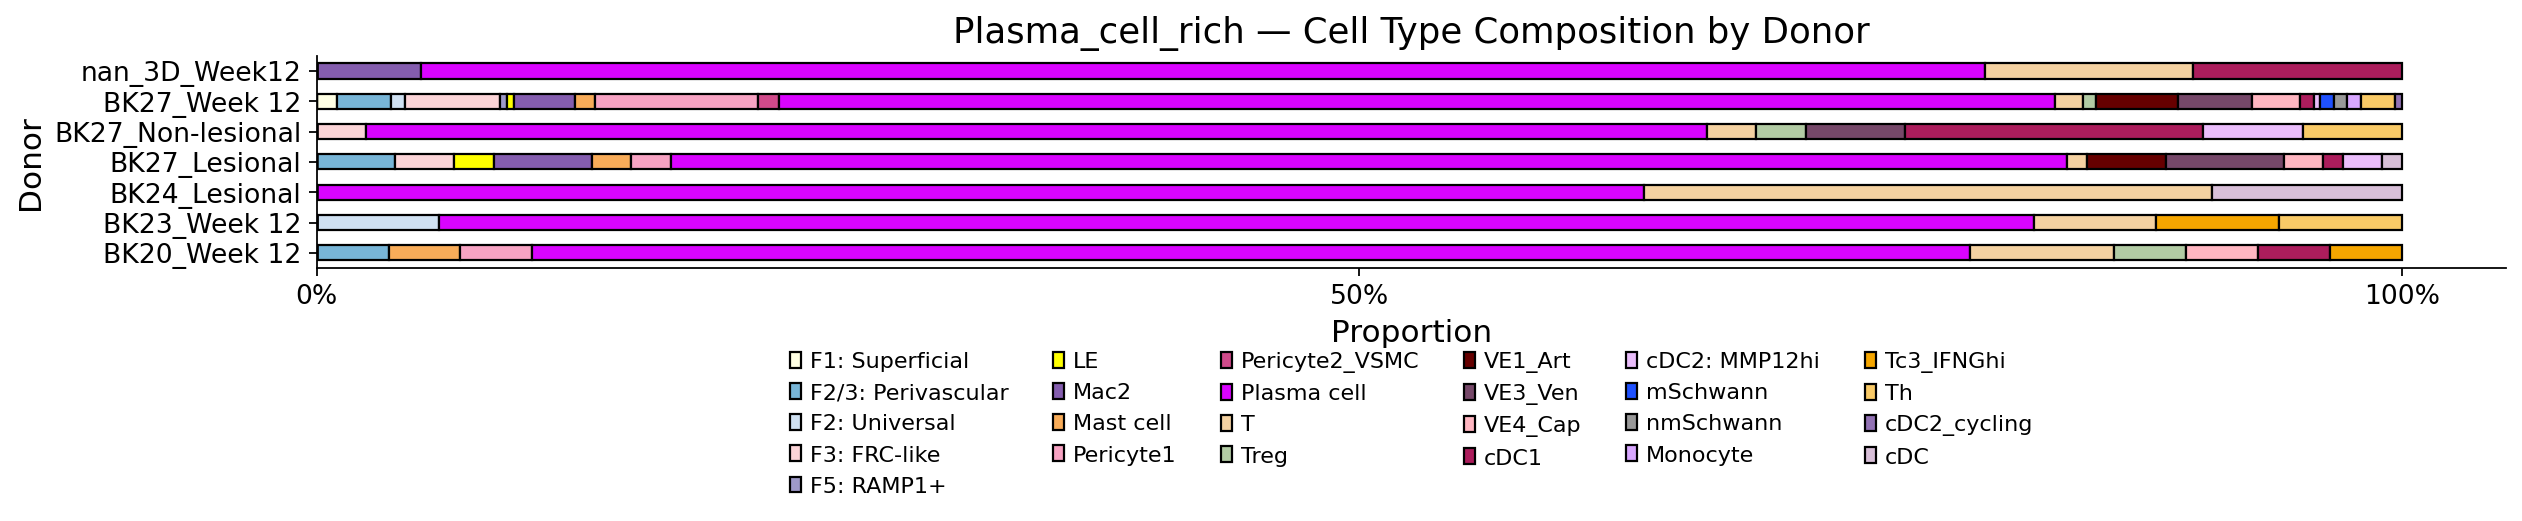

In [8]:
import numpy as np

# Create the 'info_id2' column with the conditional logic
adata_5k.obs["info_id7"] = np.where(
    adata_5k.obs["disease_overall"] == "Psoriasis", 
    adata_5k.obs["info_id6"], 
    adata_5k.obs["Sanger patient ID"].astype(str) + "_" + adata_5k.obs["Site_status"].astype(str)
)
# --------------------------
# Parameters
# --------------------------
NICHE_FILTER = "Plasma_cell_rich"
MIN_CELLS_PER_DONOR = 10
MIN_PERCENT_FOR_TEXT = 5
SECTION_ID = 'info_id7'

# --------------------------
# Filter AnnData
# --------------------------


adata_filtered = adata_5k[adata_5k.obs["niche19"] == NICHE_FILTER]
donor_counts = adata_filtered.obs[SECTION_ID].value_counts()
valid_donors = donor_counts[donor_counts > MIN_CELLS_PER_DONOR].index
adata_filtered = adata_filtered[adata_filtered.obs[SECTION_ID].isin(valid_donors)]

# --------------------------
# Tabulate cell type counts per donor
# --------------------------
df = adata_filtered.obs[[SECTION_ID, "lvl5_annotation"]].copy()
grouped = df.groupby([SECTION_ID, "lvl5_annotation"]).size().reset_index(name="cell_count")
pivot = grouped.pivot(index=SECTION_ID, columns="lvl5_annotation", values="cell_count").fillna(0)

# Sort columns to match color dict order (if applicable)
ordered_celltypes = [ct for ct in colors.keys() if ct in pivot.columns]
pivot = pivot[ordered_celltypes]

# Normalize rows to percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# --------------------------
# Build color palette
# --------------------------
plot_colors = [colors.get(cell_type, "grey") for cell_type in ordered_celltypes]

# --------------------------
# Plot
# --------------------------
fig, ax = plt.subplots(figsize=(16, 4))
bars = proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# # Annotate bars with cell type names
# for i, (idx, row) in enumerate(proportions.iterrows()):
#     cum_width = 0
#     for j, val in enumerate(row):
#         if val > MIN_PERCENT_FOR_TEXT:
#             ax.text(
#                 cum_width + val / 2,
#                 i,
#                 ordered_celltypes[j],
#                 ha='center',
#                 va='center',
#                 fontsize=10,
#                 color='black',
#                 clip_on=True
#             )
#         cum_width += val

# --------------------------
# Aesthetics
# --------------------------
ax.set_ylabel("Donor", fontsize=14)
ax.set_xlabel("Proportion", fontsize=14)
ax.set_title(f"{NICHE_FILTER} — Cell Type Composition by Donor", fontsize=16)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=12)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=12)

# Legend
ax.legend(
    title=None,
    labels=ordered_celltypes,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=6,
    fontsize=10,
    frameon=False
)

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig4/supp_plasmacomposition.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [9]:
adata_5k[adata_5k.obs["niche19"]=="Plasma_cell_rich"].obs.lvl5_annotation.value_counts()

lvl5_annotation
Plasma cell           371
Pericyte1              27
VE3_Ven                19
Mac2                   18
F3: FRC-like           18
VE1_Art                16
T                      14
F2/3: Perivascular     13
cDC1                   12
VE4_Cap                10
Th                      8
Mast cell               6
cDC2: MMP12hi           5
Treg                    4
F1: Superficial         3
F2: Universal           3
LE                      3
Pericyte2_VSMC          3
Monocyte                2
cDC                     2
Tc3_IFNGhi              2
nmSchwann               2
mSchwann                2
F5: RAMP1+              1
cDC2_cycling            1
Name: count, dtype: int64

In [10]:
# sorted(adata_filtered.obs['info_id7'].unique())

In [11]:
# li = ['BK20_Week 12',
#  'BK23_Week 12',
#   'BK27_Week 12',
#  'BK24_Lesional Baseline',
#  'BK27_Lesional Baseline',
#  'BK27_Non-lesional Baseline',
# ]
# li[::-1]

In [12]:
custom_order = sorted(adata_filtered.obs['info_id7'].unique())
# ['BK20_Week 12',
#  'BK23_Week 12',
#  'BK24_Lesional Baseline',
#  'BK27_Lesional Baseline',
#  'BK27_Non-lesional Baseline',
#  'BK27_Week 12',
#  'nan_Psoriasis_replicate_PostRx']

In [13]:
# RENAME = {'Week 12':'Week 12',
#           'Non-lesional Baseline': "NL",
#           'Lesional Baseline': "L"
#          }
# adata_filtered.obs["Timepoint3"] = adata_filtered.obs["Timepoint2"].map(RENAME)

In [14]:
1

1

In [15]:
adata_filtered.obs["lvl5_annotation"].value_counts()

lvl5_annotation
Plasma cell           341
Pericyte1              27
VE3_Ven                19
F3: FRC-like           18
VE1_Art                16
Mac2                   15
T                      14
F2/3: Perivascular     13
cDC1                   12
VE4_Cap                10
Th                      8
Mast cell               6
cDC2: MMP12hi           5
Treg                    4
F1: Superficial         3
F2: Universal           3
LE                      3
Pericyte2_VSMC          3
Monocyte                2
cDC                     2
Tc3_IFNGhi              2
nmSchwann               2
mSchwann                2
F5: RAMP1+              1
cDC2_cycling            1
Name: count, dtype: int64

In [16]:
custom_order = [ 'BK27_Non-lesional',
  'BK24_Lesional',
 'BK27_Lesional',
 'BK20_Week 12',
 'BK23_Week 12',
 'BK27_Week 12']

In [31]:
adata_5k.obs["lvl5_annotation"].value_counts()

lvl5_annotation
KC3                 189820
KC1                 126090
F2: Universal       100872
Pericyte1            85232
VE3_Ven              69056
                     ...  
Neutrophil              17
KC_HF: HS               14
ILC_Prolif              12
Mac_CX3CR1+              8
ILC1_NCR2+P2RX7+         8
Name: count, Length: 100, dtype: int64

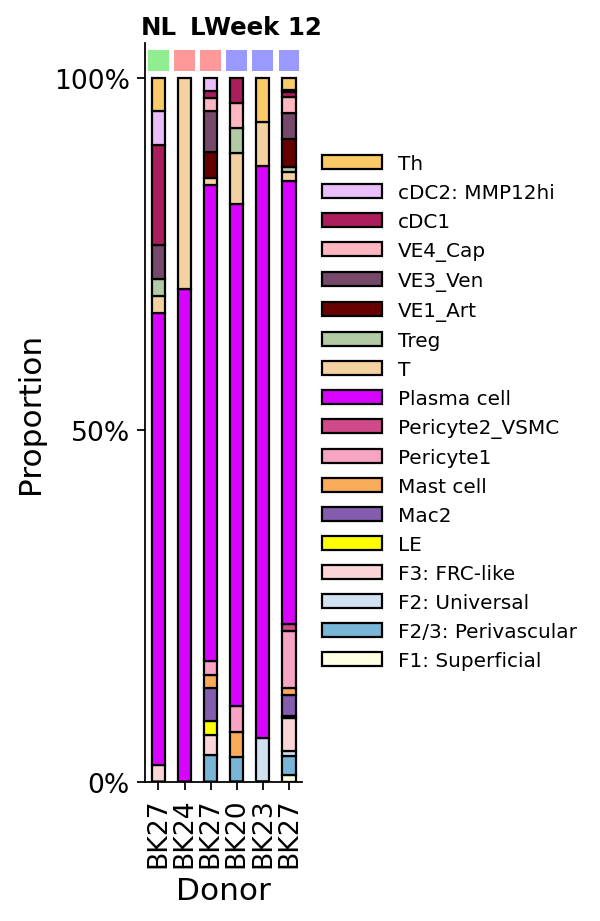

In [17]:


# --------------------------
# Parameters
# --------------------------
NICHE_FILTER = "Plasma_cell_rich"
MIN_CELLS_PER_DONOR = 10
MIN_PERCENT_FOR_TEXT = 5

# --------------------------
# Filter AnnData
# --------------------------
adata_filtered = adata_5k[adata_5k.obs["niche19"] == NICHE_FILTER]
donor_counts = adata_filtered.obs[SECTION_ID].value_counts()
valid_donors = donor_counts[donor_counts > MIN_CELLS_PER_DONOR].index
adata_filtered = adata_filtered[adata_filtered.obs[SECTION_ID].isin(valid_donors)]
celltype_counts = adata_filtered.obs["lvl5_annotation"].value_counts()
valid_celltypes = celltype_counts[celltype_counts > 2].index
adata_filtered = adata_filtered[adata_filtered.obs["lvl5_annotation"].isin(valid_celltypes)]
# --------------------------
# Tabulate cell type counts per donor
# --------------------------
df = adata_filtered.obs[[SECTION_ID, "lvl5_annotation"]].copy()
grouped = df.groupby([SECTION_ID, "lvl5_annotation"]).size().reset_index(name="cell_count")
pivot = grouped.pivot(index=SECTION_ID, columns="lvl5_annotation", values="cell_count").fillna(0)

# Sort columns to match color dict order (if applicable)
ordered_celltypes = [ct for ct in colors.keys() if ct in pivot.columns]
pivot = pivot[ordered_celltypes]

# Normalize rows to percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100
proportions = proportions.reindex(custom_order)
# --------------------------
# Build color palette
# --------------------------
plot_colors = [colors.get(cell_type, "grey") for cell_type in ordered_celltypes]

# --------------------------
# Plot
# --------------------------
fig, ax = plt.subplots(figsize=(4, 6))
bars = proportions.plot(
    kind="bar",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# --------------------------
# Aesthetics
# --------------------------
ax.set_xlabel("Donor", fontsize=14)
ax.set_ylabel("Proportion", fontsize=14)
ax.set_title(f"", fontsize=16)
ax.set_xticks(range(len(proportions)))
short_labels = [x.split("_")[0] for x in proportions.index]
ax.set_xticklabels(short_labels, rotation=90, fontsize=12)
ax.set_yticks([0, 50, 100])
ax.set_yticklabels(["0%", "50%", "100%"], fontsize=12)

# Get handles and labels from plot
# handles, labels = ax.get_legend_handles_labels()

# # # Legend below plot, 1 column, wider color boxes
# ax.legend(
#     handles, labels,
#     bbox_to_anchor=(0.5, -0.45),
#     loc="upper center",
#     ncol=1,
#     fontsize=6,
#     frameon=False,
#     handlelength=3,
#     handletextpad=0.8,
#     columnspacing=1.0
# )

handles, labels = ax.get_legend_handles_labels()
handles = handles[::-1]
labels = labels[::-1]

ax.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),  # slightly outside plot
    ncol=1,
    fontsize=9,
    frameon=False,
    handlelength=3,
    handletextpad=0.8,
    columnspacing=1.0
)


# ---- Timepoint overlay annotations above bars ----
# Define the timepoint groupings manually
timepoints = ["NL", "L", "L", "Week12", "Week12", "Week12"]  # in order of bars
timepoint_colors = {
    "NL": "#90EE90",       # light grey
    "L": "#FF9999",        # soft red
    "Week12": "#9999FF"    # soft blue
}

# Get x-tick positions
bar_positions = np.arange(len(proportions))

# Add a small colored bar above each x-bar to indicate timepoint
for xpos, tp in zip(bar_positions, timepoints):
    ax.add_patch(plt.Rectangle(
        (xpos - 0.4, 101),    # slightly wider than the bar, above 100%
        width=0.8,
        height=3,
        color=timepoint_colors.get(tp, "grey"),
        clip_on=False,
        linewidth=0
    ))
# # Add timepoint labels above the colored bars
# for xpos, tp in zip(bar_positions, timepoints):
#     ax.text(
#         xpos,            # x-position
#         104.5,           # y-position slightly above the colored bar
#         tp,              # label text
#         ha='center',
#         va='bottom',
#         fontsize=10,
#         color='black',
#         clip_on=False
#     )
# Adjust y-limit so there's space for labels above bars
ax.set_ylim(0, 115)

# Group definitions: (label, start_index, end_index)
groups = [
    ("NL", 0, 0),
    ("L", 1, 2),
    ("Week 12", 3, 5)
]

# Draw rectangles and labels above bars
for label, start, end in groups:
    x_center = (start + end) / 2
    width = end - start + 1

    # # Colored bar (already drawn earlier, but repeat here if needed)
    # ax.add_patch(
    #     plt.Rectangle(
    #         (start - 0.5, 101),      # x, y
    #         width,                   # width
    #         3,                       # height
    #         color="lightgrey",       # neutral background bar
    #         transform=ax.transData,
    #         zorder=0
    #     )
    # )

    # Label centered above the group
    ax.text(
        x_center,
        105.5,                      # y-position
        label,
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Extend y-limit to fit the annotation bars
ax.set_ylim(0, 105)

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig3e_narrower.pdf", dpi=300, bbox_inches="tight")

plt.show()



In [18]:
0

0

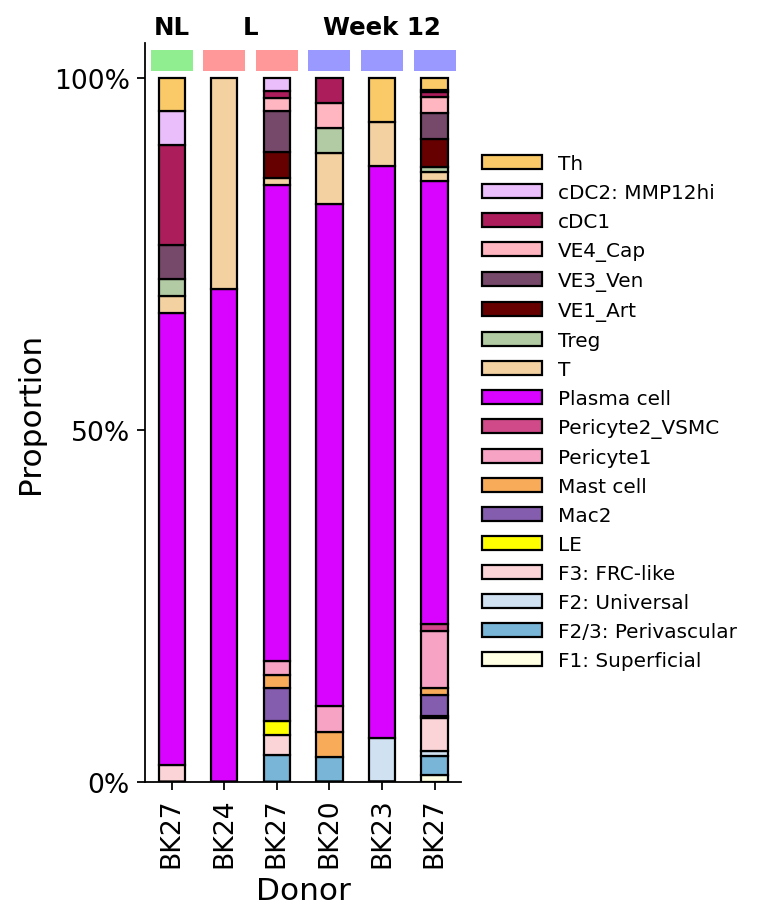

niche19
Plasma_cell_rich    520
Name: count, dtype: int64


In [19]:


# --------------------------
# Parameters
# --------------------------
NICHE_FILTER = "Plasma_cell_rich"
MIN_CELLS_PER_DONOR = 10
MIN_PERCENT_FOR_TEXT = 5
MIN_CELL = 2

# --------------------------
# Filter AnnData
# --------------------------
adata_filtered = adata_5k[adata_5k.obs["niche19"] == NICHE_FILTER]
donor_counts = adata_filtered.obs[SECTION_ID].value_counts()
valid_donors = donor_counts[donor_counts > MIN_CELLS_PER_DONOR].index
adata_filtered = adata_filtered[adata_filtered.obs[SECTION_ID].isin(valid_donors)]
celltype_counts = adata_filtered.obs["lvl5_annotation"].value_counts()
valid_celltypes = celltype_counts[celltype_counts > MIN_CELL].index
adata_filtered = adata_filtered[adata_filtered.obs["lvl5_annotation"].isin(valid_celltypes)]
# --------------------------
# Tabulate cell type counts per donor
# --------------------------
df = adata_filtered.obs[[SECTION_ID, "lvl5_annotation"]].copy()
grouped = df.groupby([SECTION_ID, "lvl5_annotation"]).size().reset_index(name="cell_count")
pivot = grouped.pivot(index=SECTION_ID, columns="lvl5_annotation", values="cell_count").fillna(0)

# Sort columns to match color dict order (if applicable)
ordered_celltypes = [ct for ct in colors.keys() if ct in pivot.columns]
pivot = pivot[ordered_celltypes]

# Normalize rows to percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100
proportions = proportions.reindex(custom_order)
# --------------------------
# Build color palette
# --------------------------
plot_colors = [colors.get(cell_type, "grey") for cell_type in ordered_celltypes]

# --------------------------
# Plot
# --------------------------
fig, ax = plt.subplots(figsize=(5, 6))
bars = proportions.plot(
    kind="bar",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# --------------------------
# Aesthetics
# --------------------------
ax.set_xlabel("Donor", fontsize=14)
ax.set_ylabel("Proportion", fontsize=14)
ax.set_title(f"", fontsize=16)
ax.set_xticks(range(len(proportions)))
short_labels = [x.split("_")[0] for x in proportions.index]
ax.set_xticklabels(short_labels, rotation=90, fontsize=12)
ax.set_yticks([0, 50, 100])
ax.set_yticklabels(["0%", "50%", "100%"], fontsize=12)

# Get handles and labels from plot
# handles, labels = ax.get_legend_handles_labels()

# # # Legend below plot, 1 column, wider color boxes
# ax.legend(
#     handles, labels,
#     bbox_to_anchor=(0.5, -0.45),
#     loc="upper center",
#     ncol=1,
#     fontsize=6,
#     frameon=False,
#     handlelength=3,
#     handletextpad=0.8,
#     columnspacing=1.0
# )

handles, labels = ax.get_legend_handles_labels()
handles = handles[::-1]
labels = labels[::-1]

ax.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),  # slightly outside plot
    ncol=1,
    fontsize=9,
    frameon=False,
    handlelength=3,
    handletextpad=0.8,
    columnspacing=1.0
)


# ---- Timepoint overlay annotations above bars ----
# Define the timepoint groupings manually
timepoints = ["NL", "L", "L", "Week12", "Week12", "Week12"]  # in order of bars
timepoint_colors = {
    "NL": "#90EE90",       # light grey
    "L": "#FF9999",        # soft red
    "Week12": "#9999FF"    # soft blue
}

# Get x-tick positions
bar_positions = np.arange(len(proportions))

# Add a small colored bar above each x-bar to indicate timepoint
for xpos, tp in zip(bar_positions, timepoints):
    ax.add_patch(plt.Rectangle(
        (xpos - 0.4, 101),    # slightly wider than the bar, above 100%
        width=0.8,
        height=3,
        color=timepoint_colors.get(tp, "grey"),
        clip_on=False,
        linewidth=0
    ))
# # Add timepoint labels above the colored bars
# for xpos, tp in zip(bar_positions, timepoints):
#     ax.text(
#         xpos,            # x-position
#         104.5,           # y-position slightly above the colored bar
#         tp,              # label text
#         ha='center',
#         va='bottom',
#         fontsize=10,
#         color='black',
#         clip_on=False
#     )
# Adjust y-limit so there's space for labels above bars
ax.set_ylim(0, 115)

# Group definitions: (label, start_index, end_index)
groups = [
    ("NL", 0, 0),
    ("L", 1, 2),
    ("Week 12", 3, 5)
]

# Draw rectangles and labels above bars
for label, start, end in groups:
    x_center = (start + end) / 2
    width = end - start + 1

    # # Colored bar (already drawn earlier, but repeat here if needed)
    # ax.add_patch(
    #     plt.Rectangle(
    #         (start - 0.5, 101),      # x, y
    #         width,                   # width
    #         3,                       # height
    #         color="lightgrey",       # neutral background bar
    #         transform=ax.transData,
    #         zorder=0
    #     )
    # )

    # Label centered above the group
    ax.text(
        x_center,
        105.5,                      # y-position
        label,
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Extend y-limit to fit the annotation bars
ax.set_ylim(0, 105)

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig_plasma_cell_comnposition.pdf", dpi=300, bbox_inches="tight")

plt.show()

print(adata_filtered.obs["niche19"].value_counts())

In [30]:
{x:x for x in sorted(adata_filtered.obs["lvl5_annotation"].unique())}

{'F1: Superficial': 'F1: Superficial',
 'F2/3: Perivascular': 'F2/3: Perivascular',
 'F2: Universal': 'F2: Universal',
 'F3: FRC-like': 'F3: FRC-like',
 'F5: RAMP1+': 'F5: RAMP1+',
 'LE': 'LE',
 'Mac2': 'Mac2',
 'Mast cell': 'Mast cell',
 'Monocyte': 'Monocyte',
 'Pericyte1': 'Pericyte1',
 'Pericyte2_VSMC': 'Pericyte2_VSMC',
 'Plasma cell': 'Plasma cell',
 'T': 'T',
 'Tc3_IFNGhi': 'Tc3_IFNGhi',
 'Th': 'Th',
 'Treg': 'Treg',
 'VE1_Art': 'VE1_Art',
 'VE3_Ven': 'VE3_Ven',
 'VE4_Cap': 'VE4_Cap',
 'cDC': 'cDC',
 'cDC1': 'cDC1',
 'cDC2: MMP12hi': 'cDC2: MMP12hi',
 'cDC2_cycling': 'cDC2_cycling',
 'mSchwann': 'mSchwann',
 'nmSchwann': 'nmSchwann'}

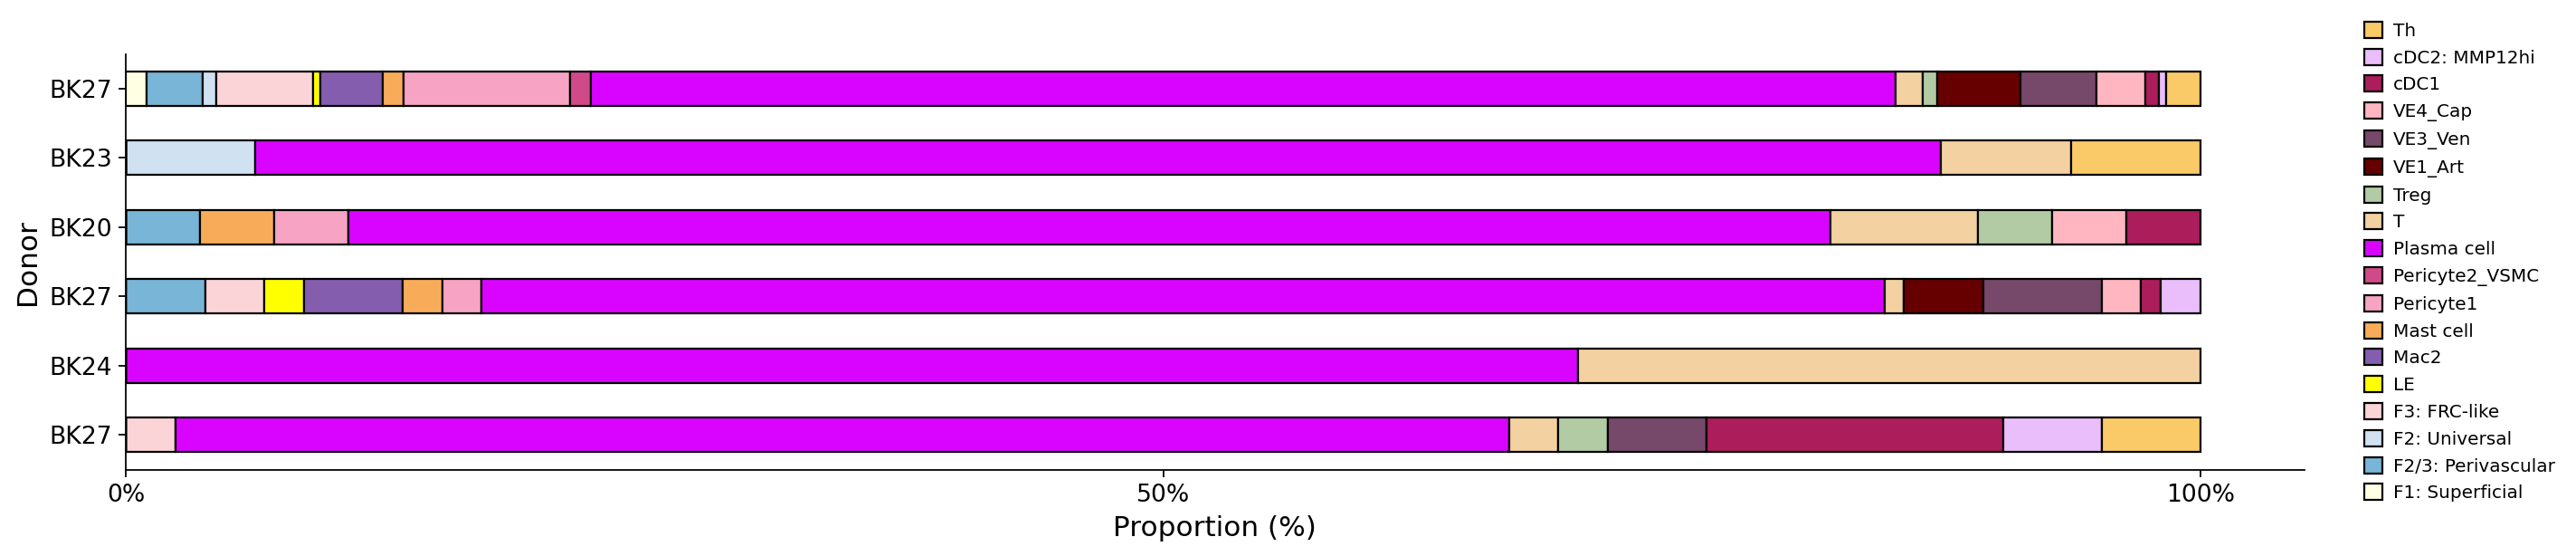

In [20]:
# --------------------------
# Plot (horizontal bars)
# --------------------------
fig, ax = plt.subplots(figsize=(18, 4))  # wider, less tall

bars = proportions.plot(
    kind="barh",            # horizontal stacked bar
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# --------------------------
# Aesthetics (swapped axes)
# --------------------------
ax.set_ylabel("Donor", fontsize=14)
ax.set_xlabel("Proportion (%)", fontsize=14)
ax.set_title("", fontsize=16)

# Donor labels
short_labels = [x.split("_")[0] for x in proportions.index]
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(short_labels, fontsize=12)

# Percent ticks
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=12)

# --------------------------
# Legend
# --------------------------
handles, labels = ax.get_legend_handles_labels()
handles, labels = handles[::-1], labels[::-1]

# Smaller, squarer legend boxes
ax.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    fontsize=9,
    frameon=False,
    handlelength=1.0,      # shorter = more square
    handleheight=1.0,      # make boxes less rectangular
    handletextpad=0.6,
    columnspacing=0.8
)

# --------------------------
# Final formatting
# --------------------------
ax.set_xlim(0, 105)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig_plasma_cell_composition_horizontal.pdf", dpi=300, bbox_inches="tight")
plt.show()

     

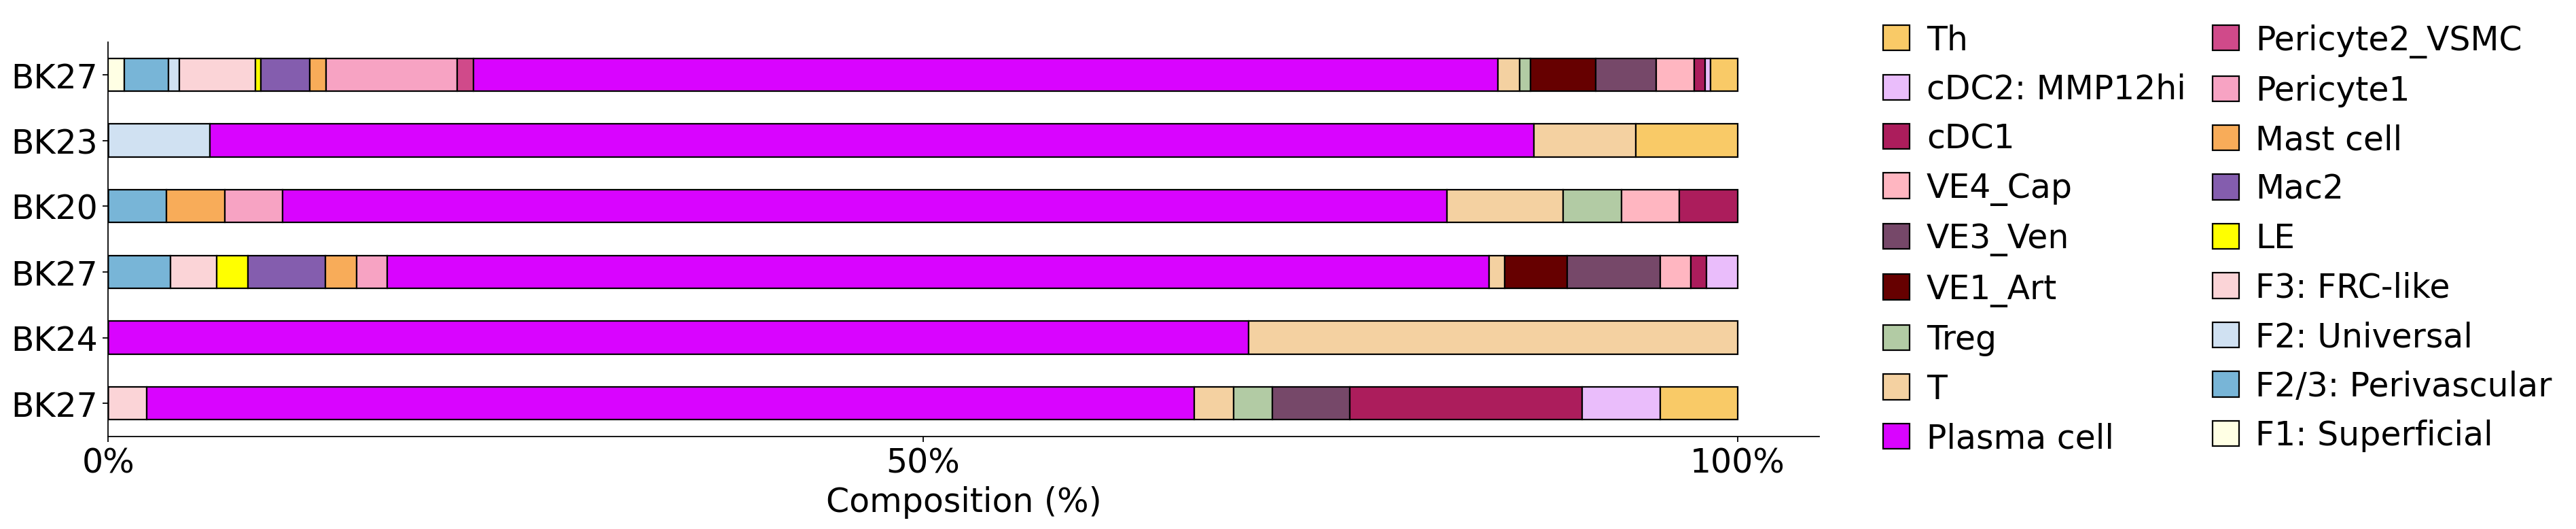

In [21]:
# --------------------------
# Plot (horizontal bars)
# --------------------------
fig, ax = plt.subplots(figsize=(24, 5))  # wider, slightly taller to fit text

bars = proportions.plot(
    kind="barh",            # horizontal stacked bar
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# --------------------------
# Aesthetics (swapped axes)
# --------------------------
ax.set_ylabel("", fontsize=16)
ax.set_xlabel("Composition (%)", fontsize=22)
ax.set_title("", fontsize=1)

# Donor labels
short_labels = [x.split("_")[0] for x in proportions.index]
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(short_labels, fontsize=22)

# Percent ticks
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=22)

# --------------------------
# Legend
# --------------------------
handles, labels = ax.get_legend_handles_labels()
handles, labels = handles[::-1], labels[::-1]   # reverse order

# Smaller, squarer legend boxes; two columns, larger font
ax.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=2,                # two columns
    fontsize=22,           # larger legend font
    frameon=False,
    handlelength=0.8,      # make squares compact
    handleheight=0.8,
    handletextpad=0.5,
    columnspacing=0.8
)

# --------------------------
# Final formatting
# --------------------------
ax.set_xlim(0, 105)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig_plasma_cell_composition_horizontal.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
adata_filtered.obs["lvl5_annotation"].value_counts()


lvl5_annotation
Plasma cell           341
Pericyte1              27
VE3_Ven                19
F3: FRC-like           18
VE1_Art                16
Mac2                   15
T                      14
F2/3: Perivascular     13
cDC1                   12
VE4_Cap                10
Th                      8
Mast cell               6
cDC2: MMP12hi           5
Treg                    4
F1: Superficial         3
Pericyte2_VSMC          3
F2: Universal           3
LE                      3
Name: count, dtype: int64

In [23]:
2

2

/tmp/ipykernel_3836113/2303477865.py:71: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


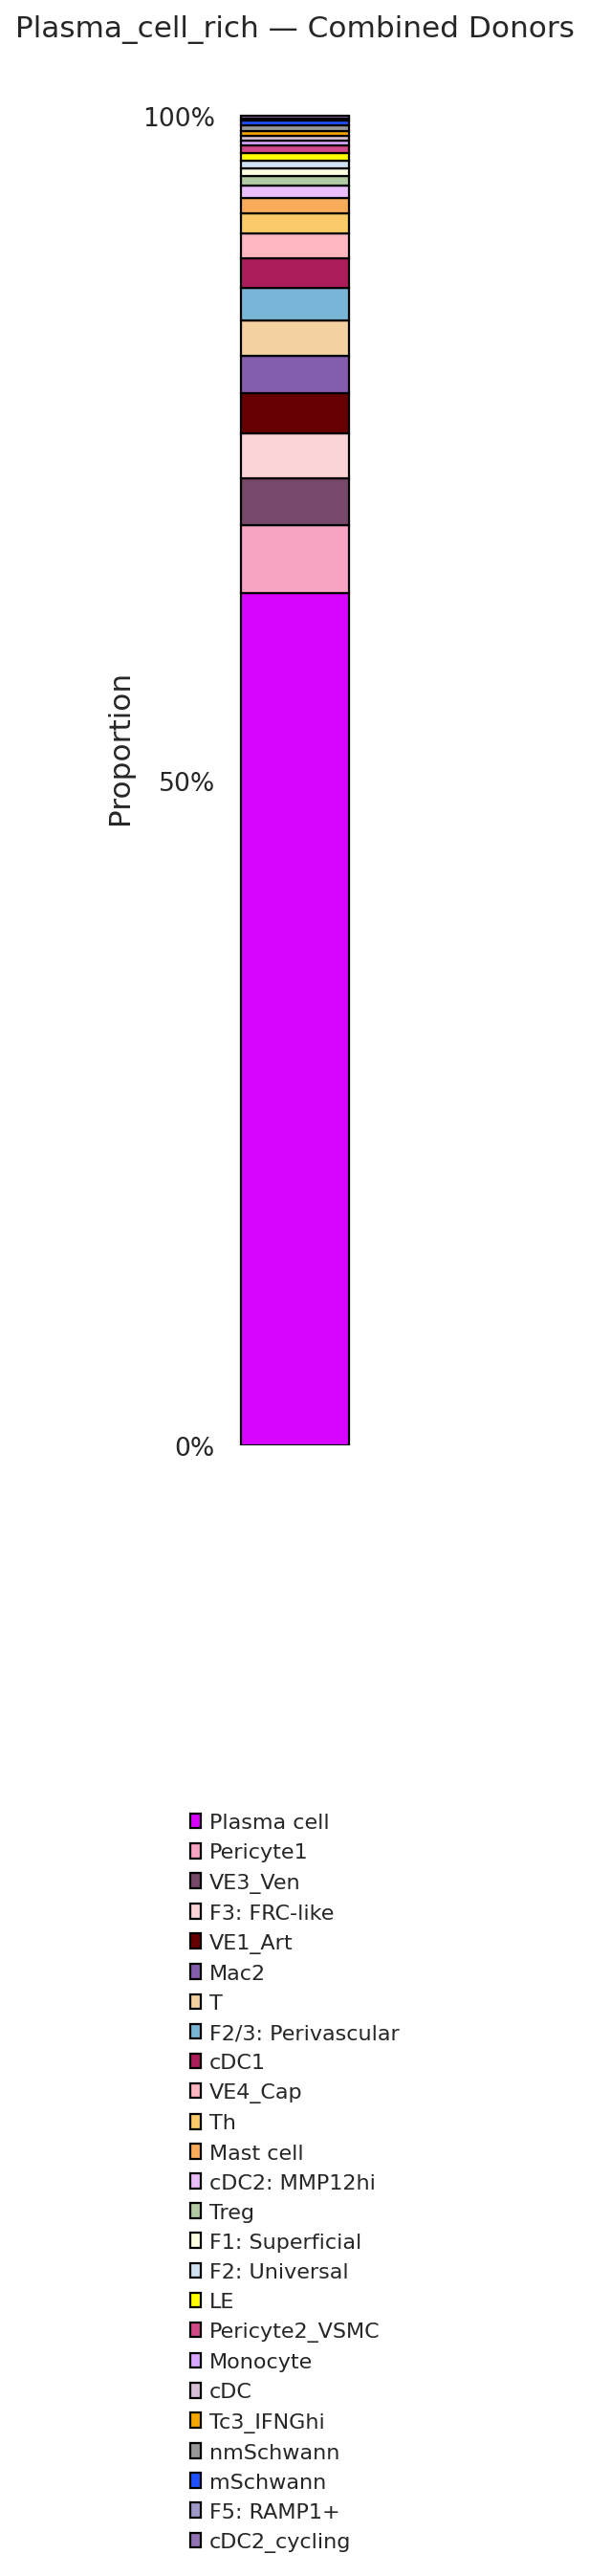

In [24]:


# --------------------------
# Parameters
# --------------------------
NICHE_FILTER = "Plasma_cell_rich"
MIN_CELLS_PER_DONOR = 10

# --------------------------
# Filter AnnData
# --------------------------
adata_filtered = adata_5k[adata_5k.obs["niche19"] == NICHE_FILTER]
donor_counts = adata_filtered.obs[SECTION_ID].value_counts()
valid_donors = donor_counts[donor_counts > MIN_CELLS_PER_DONOR].index
adata_filtered = adata_filtered[adata_filtered.obs[SECTION_ID].isin(valid_donors)]

# --------------------------
# Total counts across all donors
# --------------------------
df = adata_filtered.obs["lvl5_annotation"].value_counts().to_frame("cell_count")
df = df.loc[df.index.intersection(colors.keys())]  # restrict to color dict keys
df = df.loc[df["cell_count"] > 0]  # ensure non-zero

# Normalize to proportions
df["proportion"] = df["cell_count"] / df["cell_count"].sum() * 100

# --------------------------
# Color palette
# --------------------------
ordered_celltypes = df.index.tolist()
plot_colors = [colors.get(ct, "grey") for ct in ordered_celltypes]

# --------------------------
# Plot: Single Stacked Bar
# --------------------------
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(1, 12))

left = 0
for idx, ct in enumerate(ordered_celltypes):
    width = df.loc[ct, "proportion"]
    ax.bar(
        x=0,
        height=width,
        bottom=left,
        color=plot_colors[idx],
        edgecolor="black",
        width=0.8,
        label=ct
    )
    left += width

# --------------------------
# Cosmetics
# --------------------------
ax.set_xticks([])
ax.set_ylabel("Proportion", fontsize=14)
ax.set_title(f"{NICHE_FILTER} — Combined Donors", fontsize=14)
ax.set_yticks([0, 50, 100])
ax.set_yticklabels(["0%", "50%", "100%"], fontsize=12)
sns.despine(left=True, bottom=True)

# Legend below
ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=1,
    fontsize=10,
    frameon=False
)

plt.tight_layout()
plt.show()

# simple version

In [45]:
RENAME = {'F1: Superficial': 'Fibroblast',
 'F2/3: Perivascular': 'Fibroblast',
 'F2: Universal': 'Fibroblast',
 'F3: FRC-like': 'Fibroblast',
 'F5: RAMP1+': 'Fibroblast',
 'LE': 'LE',
 'Mac2': 'Mac2',
 'Mast cell': 'Mast cell',
 'Monocyte': 'Mono/Mac',
 'Pericyte1': 'Pericyte',
 'Pericyte2_VSMC': 'Pericyte',
 'Plasma cell': 'Plasma cell',
 'T': 'T',
 'Tc3_IFNGhi': 'Tc3_IFNGhi',
 'Th': 'Th',
 'Treg': 'Treg',
 'VE1_Art': 'VE',
 'VE3_Ven': 'VE',
 'VE4_Cap': 'VE',
 'cDC': 'cDC2',
 'cDC1': 'cDC1',
 'cDC2: MMP12hi': 'cDC2',
 'cDC2_cycling': 'cDC2',
 'mSchwann': 'Schwann',
 'nmSchwann': 'Schwann'}
adata_5k.obs["lvl5_annotation_simple"]=adata_5k.obs["lvl5_annotation"].map(RENAME)
adata_5k.obs["lvl5_annotation_simple"].value_counts()

lvl5_annotation_simple
Fibroblast     212235
Pericyte       108080
VE             104490
T               54675
Mac2            44152
Th              28446
cDC2            22166
Schwann         21838
Mast cell       16490
LE              14702
Treg            14156
cDC1            13450
Plasma cell       879
Mono/Mac          607
Tc3_IFNGhi        500
Name: count, dtype: int64

In [58]:


# --------------------------
# Parameters
# --------------------------
NICHE_FILTER = "Plasma_cell_rich"
MIN_CELLS_PER_DONOR = 10
MIN_PERCENT_FOR_TEXT = 5
MIN_CELL = 2

# --------------------------
# Filter AnnData
# --------------------------
adata_filtered = adata_5k[adata_5k.obs["niche19"] == NICHE_FILTER]
donor_counts = adata_filtered.obs[SECTION_ID].value_counts()
valid_donors = donor_counts[donor_counts > MIN_CELLS_PER_DONOR].index
adata_filtered = adata_filtered[adata_filtered.obs[SECTION_ID].isin(valid_donors)]
celltype_counts = adata_filtered.obs["lvl5_annotation_simple"].value_counts()
valid_celltypes = celltype_counts[celltype_counts > MIN_CELL].index
adata_filtered = adata_filtered[adata_filtered.obs["lvl5_annotation_simple"].isin(valid_celltypes)]
adata_filtered.obs["lvl5_annotation_simple"].value_counts()

lvl5_annotation_simple
Plasma cell    341
VE              45
Fibroblast      38
Pericyte        30
Mac2            15
T               14
cDC1            12
Th               8
cDC2             8
Mast cell        6
Schwann          4
Treg             4
LE               3
Name: count, dtype: int64

In [59]:
# --------------------------
# Tabulate cell type counts per donor
# --------------------------
df = adata_filtered.obs[[SECTION_ID, "lvl5_annotation_simple"]].copy()
grouped = df.groupby([SECTION_ID, "lvl5_annotation_simple"]).size().reset_index(name="cell_count")
pivot = grouped.pivot(index=SECTION_ID, columns="lvl5_annotation_simple", values="cell_count").fillna(0)
pivot

# Sort columns to match color dict order (if applicable)
ordered_celltypes = [ct for ct in colors.keys() if ct in pivot.columns]
ordered_celltypes

['LE',
 'Mac2',
 'Mast cell',
 'Plasma cell',
 'T',
 'Treg',
 'VE',
 'cDC1',
 'cDC2',
 'Th',
 'Schwann',
 'Pericyte',
 'Fibroblast']

In [60]:
colors = colors | {"Fibroblast": "#BFDFFF"}
#plot_colors = [colors.get(cell_type, "grey") for cell_type in ordered_celltypes]
for x in pivot.columns:
    if x not in colors.keys():
        print(x)
    else:
        print("found: ", x)


found:  Fibroblast
found:  LE
found:  Mac2
found:  Mast cell
found:  Pericyte
found:  Plasma cell
found:  Schwann
found:  T
found:  Th
found:  Treg
found:  VE
found:  cDC1
found:  cDC2


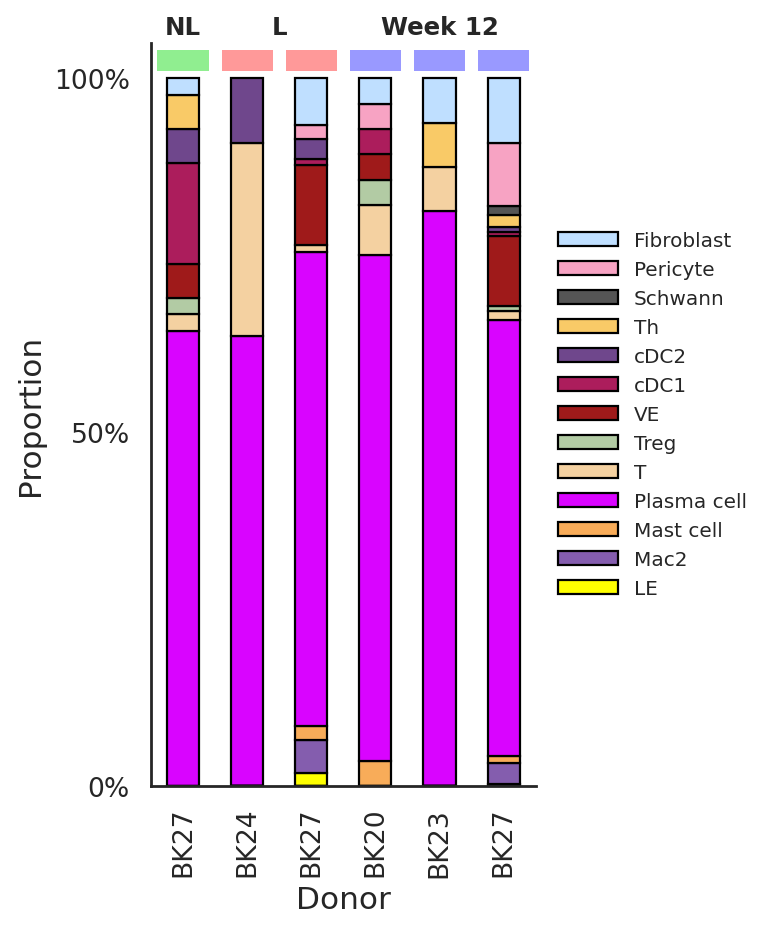

niche19
Plasma_cell_rich    528
Name: count, dtype: int64


In [61]:
pivot = pivot[ordered_celltypes]

# Normalize rows to percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100
proportions = proportions.reindex(custom_order)
# --------------------------
# Build color palette
# --------------------------
plot_colors = [colors.get(cell_type, "grey") for cell_type in ordered_celltypes]

# --------------------------
# Plot
# --------------------------
fig, ax = plt.subplots(figsize=(5, 6))
bars = proportions.plot(
    kind="bar",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# --------------------------
# Aesthetics
# --------------------------
ax.set_xlabel("Donor", fontsize=14)
ax.set_ylabel("Proportion", fontsize=14)
ax.set_title(f"", fontsize=16)
ax.set_xticks(range(len(proportions)))
short_labels = [x.split("_")[0] for x in proportions.index]
ax.set_xticklabels(short_labels, rotation=90, fontsize=12)
ax.set_yticks([0, 50, 100])
ax.set_yticklabels(["0%", "50%", "100%"], fontsize=12)

# Get handles and labels from plot
# handles, labels = ax.get_legend_handles_labels()

# # # Legend below plot, 1 column, wider color boxes
# ax.legend(
#     handles, labels,
#     bbox_to_anchor=(0.5, -0.45),
#     loc="upper center",
#     ncol=1,
#     fontsize=6,
#     frameon=False,
#     handlelength=3,
#     handletextpad=0.8,
#     columnspacing=1.0
# )

handles, labels = ax.get_legend_handles_labels()
handles = handles[::-1]
labels = labels[::-1]

ax.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),  # slightly outside plot
    ncol=1,
    fontsize=9,
    frameon=False,
    handlelength=3,
    handletextpad=0.8,
    columnspacing=1.0
)


# ---- Timepoint overlay annotations above bars ----
# Define the timepoint groupings manually
timepoints = ["NL", "L", "L", "Week12", "Week12", "Week12"]  # in order of bars
timepoint_colors = {
    "NL": "#90EE90",       # light grey
    "L": "#FF9999",        # soft red
    "Week12": "#9999FF"    # soft blue
}

# Get x-tick positions
bar_positions = np.arange(len(proportions))

# Add a small colored bar above each x-bar to indicate timepoint
for xpos, tp in zip(bar_positions, timepoints):
    ax.add_patch(plt.Rectangle(
        (xpos - 0.4, 101),    # slightly wider than the bar, above 100%
        width=0.8,
        height=3,
        color=timepoint_colors.get(tp, "grey"),
        clip_on=False,
        linewidth=0
    ))
# # Add timepoint labels above the colored bars
# for xpos, tp in zip(bar_positions, timepoints):
#     ax.text(
#         xpos,            # x-position
#         104.5,           # y-position slightly above the colored bar
#         tp,              # label text
#         ha='center',
#         va='bottom',
#         fontsize=10,
#         color='black',
#         clip_on=False
#     )
# Adjust y-limit so there's space for labels above bars
ax.set_ylim(0, 115)

# Group definitions: (label, start_index, end_index)
groups = [
    ("NL", 0, 0),
    ("L", 1, 2),
    ("Week 12", 3, 5)
]

# Draw rectangles and labels above bars
for label, start, end in groups:
    x_center = (start + end) / 2
    width = end - start + 1

    # # Colored bar (already drawn earlier, but repeat here if needed)
    # ax.add_patch(
    #     plt.Rectangle(
    #         (start - 0.5, 101),      # x, y
    #         width,                   # width
    #         3,                       # height
    #         color="lightgrey",       # neutral background bar
    #         transform=ax.transData,
    #         zorder=0
    #     )
    # )

    # Label centered above the group
    ax.text(
        x_center,
        105.5,                      # y-position
        label,
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Extend y-limit to fit the annotation bars
ax.set_ylim(0, 105)

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig_plasma_cell_comnposition_simple.pdf", dpi=300, bbox_inches="tight")

plt.show()

print(adata_filtered.obs["niche19"].value_counts())

In [63]:
# plot_colors

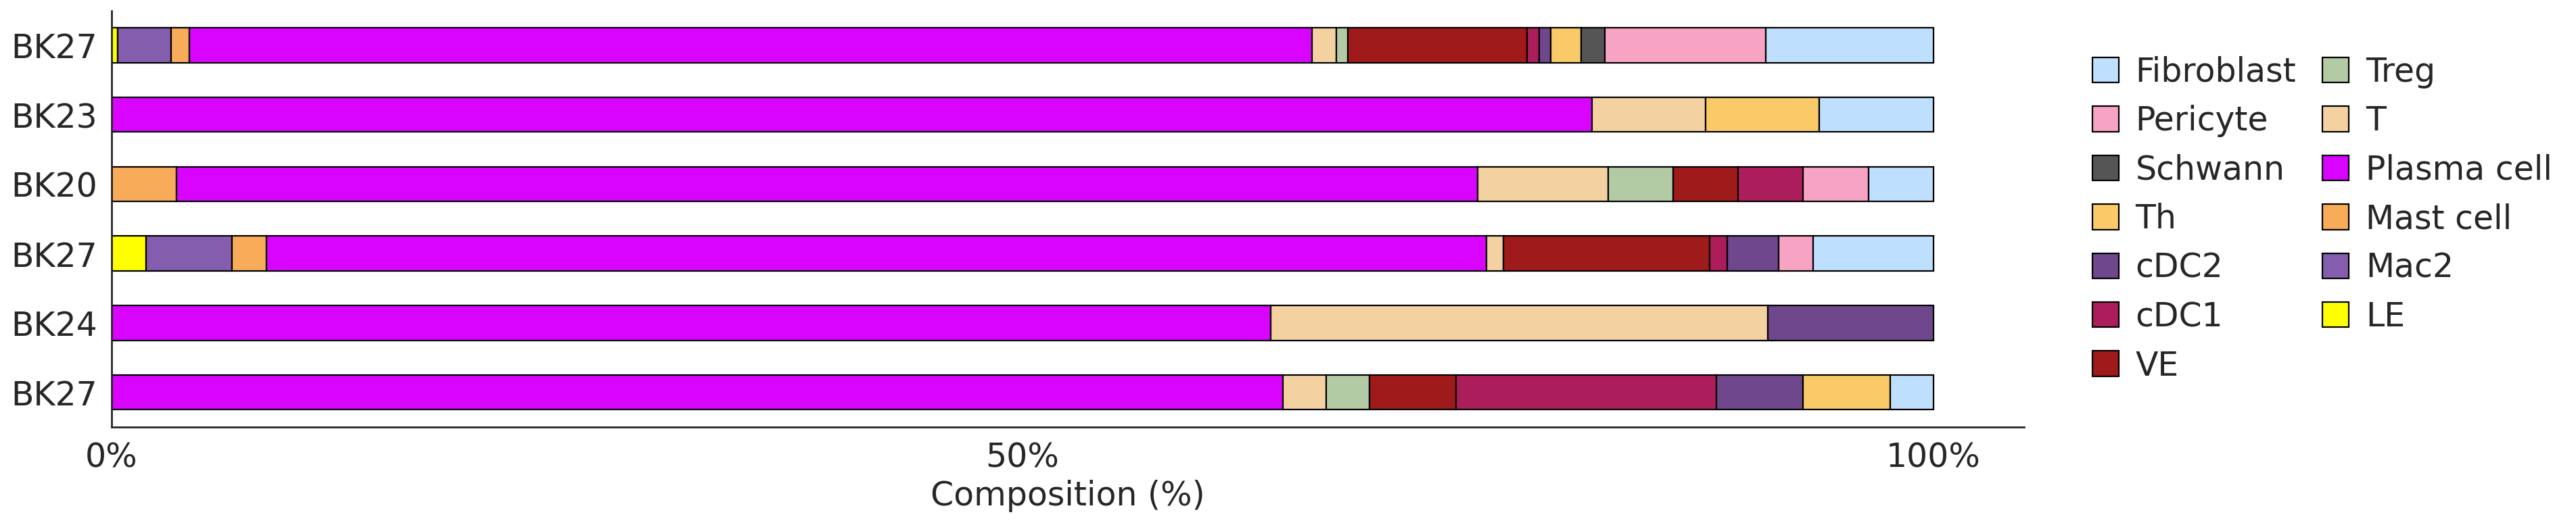

In [62]:
# --------------------------
# Plot (horizontal bars)
# --------------------------
fig, ax = plt.subplots(figsize=(24, 5))  # wider, slightly taller to fit text

bars = proportions.plot(
    kind="barh",            # horizontal stacked bar
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# --------------------------
# Aesthetics (swapped axes)
# --------------------------
ax.set_ylabel("", fontsize=16)
ax.set_xlabel("Composition (%)", fontsize=22)
ax.set_title("", fontsize=1)

# Donor labels
short_labels = [x.split("_")[0] for x in proportions.index]
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(short_labels, fontsize=22)

# Percent ticks
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=22)

# --------------------------
# Legend
# --------------------------
handles, labels = ax.get_legend_handles_labels()
handles, labels = handles[::-1], labels[::-1]   # reverse order

# Smaller, squarer legend boxes; two columns, larger font
ax.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=2,                # two columns
    fontsize=22,           # larger legend font
    frameon=False,
    handlelength=0.8,      # make squares compact
    handleheight=0.8,
    handletextpad=0.5,
    columnspacing=0.8
)

# --------------------------
# Final formatting
# --------------------------
ax.set_xlim(0, 105)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig4/fig_plasma_cell_composition_horizontal_simple.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
## adata_5k

In [26]:
# """
# find niche
# """
# sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(18,18))

# CELL_TYPE ='Plasma cell'
# MIN_NUMBER_CELLS=5
# i=0
# # try:
# #     adata_5k.uns.pop('niche_name_colors')
# # except:
# #     1

# for i, tissue_section_id in enumerate(adata_5k.obs["info_id"].unique()):
#     print(i, "/", len(adata_5k.obs["info_id"].unique()))
#     adata_i =  adata_5k[adata_5k.obs["info_id"]==tissue_section_id]
#     niche_names_found = adata_i.obs["lvl5_annotation"].unique()
   
#     if CELL_TYPE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["lvl5_annotation"]==CELL_TYPE]
#         print(tissue_section_id, " - ",  adata_ii.shape[0] , " cells")
#         if adata_ii.shape[0] > MIN_NUMBER_CELLS:     
#             i=i+1
#             print(tissue_section_id, " has ", adata_ii.shape[0])
#             sq.pl.spatial_scatter(
#                 adata_i,
#                 library_id="spatial",
#                 shape=None,
#                 color="niche_name",
#                 size=10,
#                 vmax=1,
#                 title=tissue_section_id,
#                 #ax=ax,
#                 #legend_loc="on data"  # Disable the legend for each subplot
#             )
#             adata_i.obs["test"] = [x if x == NICHE else "Other" for x in adata_i.obs["niche_name"]]
#             sq.pl.spatial_scatter(
#                     adata_i,
#                     library_id="spatial",
#                     shape=None,
#                     color="test",
#                     size=5,
#                     vmax=1,
#                     title=tissue_section_id,

#                     #ax=ax,
#                     legend_loc="on data"  # Disable the legend for each subplot
#                 )
# #             if i >30:
# #                 print("10+ samples found already ... Terminate")
# #                 break
#         else:
#              print(tissue_section_id, " - does not contain ", NICHE, " - i=", i)

In [27]:
import scanpy as sc

In [28]:
# base_dir="/nfs/team298/ls34/disease_atlas/mrvi/"
# SUBSAMPLE=True
# #adata=sc.read_h5ad(base_dir+'adata_inflamm_scanvi6_HVG8024_EPOCHS10.h5ad.v2.fordeconv.noHS.reintegratedSCANVI.updated5')
# if SUBSAMPLE:
#     adata=sc.read_h5ad(base_dir+ 'adata_inflamm_scanvi6_HVG8024_EPOCHS10.h5ad.v2.fordeconv.noHS.reintegratedSCANVI.updated5.subsampled_equal')

#    # adata=sc.read_h5ad(base_dir+'adata_inflamm_scanvi6_HVG8024_EPOCHS10.h5ad.v2.fordeconv.noHS.reintegratedSCANVI.updated5.subsampled10percent_nopsoriasis')
# else:
#     adata=sc.read_h5ad(base_dir+'adata_inflamm_scanvi6_HVG8024_EPOCHS10.h5ad.v2.fordeconv.noHS.reintegratedSCANVI.updated10')


In [29]:
 stop

NameError: name 'stop' is not defined

In [ ]:
KEEP = ["Sweat gland channel inner",
        "Sweat gland channel outer",
        "Sweat gland channel",    
        
        "Sweat gland",'Sweat gland myoepithelial'
         'KC_HF/SC: LGR6+ACTA2+',
        "Bcell", "Plasma cell", ]

adata_i=adata[adata.obs["lvl5_annotation"].isin(KEEP)] 
LIGANDS = {"Ligands": ["CCL28", "CCL20", "TNFSF13", "TNFSF13B"],
           "Ab transfer": "PIGR"}
RECEPTORS = {"Receptors": ["CCR10","CCR6", "TNFRSF13B", "TNFRSF13C"]}

CATEGORY="lvl5_annotation"
adata_i.shape

In [ ]:

sc.pl.DotPlot(
    adata_i,
   LIGANDS,
    #swap_axes=True,
    groupby=CATEGORY,  #    colorbar_title='Mean expression\n(variance scaled)', 
    standard_scale="var",
) \
    .style(cmap='Reds', color_on='square', dot_edge_color='black', dot_edge_lw=1, grid=True).show()



sc.pl.DotPlot(
    adata_i,
   RECEPTORS,
    #swap_axes=True,
    groupby=CATEGORY,  #    colorbar_title='Mean expression\n(variance scaled)', 
    standard_scale="var",
) \
    .style(cmap='Reds', color_on='square', dot_edge_color='black', dot_edge_lw=1, grid=True).show()


# sc.pl.DotPlot(
#     adata_5k_ii,
#    remove_markers(TREGS),
#     #swap_axes=True,
#     groupby=CATEGORY,  #    colorbar_title='Mean expression\n(variance scaled)', 
#     standard_scale="var",) \
#     .style(cmap='Reds', color_on='square', dot_edge_color='black', dot_edge_lw=1, grid=True).show()


In [ ]:

sc.pl.DotPlot(
    adata_i,
   LIGANDS,
    #swap_axes=True,
    groupby=CATEGORY,  #    colorbar_title='Mean expression\n(variance scaled)', 
   # standard_scale="var",
) \
    .style(cmap='Reds', color_on='square', dot_edge_color='black', dot_edge_lw=1, grid=True).show()



sc.pl.DotPlot(
    adata_i,
   RECEPTORS,
    #swap_axes=True,
    groupby=CATEGORY,  #    colorbar_title='Mean expression\n(variance scaled)', 
 #   standard_scale="var",
) \
    .style(cmap='Reds', color_on='square', dot_edge_color='black', dot_edge_lw=1, grid=True).show()


# sc.pl.DotPlot(
#     adata_5k_ii,
#    remove_markers(TREGS),
#     #swap_axes=True,
#     groupby=CATEGORY,  #    colorbar_title='Mean expression\n(variance scaled)', 
#     standard_scale="var",) \
#     .style(cmap='Reds', color_on='square', dot_edge_color='black', dot_edge_lw=1, grid=True).show()
